# DK ↔ EP Title Embeddings

Embed translated Danish Folketinget roll-call titles and European Parliament vote titles with `all-mpnet-base-v2`, save vectors, and check whether the two corpora sit close or far apart in embedding space.

Spec: `docs/superpowers/specs/2026-09-21-dk-ep-title-embeddings-design.md`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_DIR = Path("..")
DK_PATH = PROJECT_DIR / "data" / "temp_data" / "parliament" / "roll_calls_translated.csv"
EP_DATA_DIR = PROJECT_DIR / "EP" / "EP-data"
EP_PERIODS = ["2009-2014", "2014-2019", "2019-2024", "2024-2029"]
OUT_DIR = PROJECT_DIR / "data" / "temp_data" / "embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
RANDOM_STATE = 42

In [2]:
df_dk = pd.read_csv(DK_PATH)
df_dk = df_dk.dropna(subset=["sag_titel_en"]).copy()
df_dk["sag_titel_en"] = df_dk["sag_titel_en"].astype(str).str.strip()
df_dk = df_dk[df_dk["sag_titel_en"].str.len() > 0].reset_index(drop=True)

print(f"DK titles: {len(df_dk):,}")
print(df_dk[["afstemningid", "sag_titel", "sag_titel_en"]].head(3))

DK titles: 2,128
   afstemningid  ...                                       sag_titel_en
0             2  ...  Proposal for a law amending the Corporate Tax ...
1          1783  ...  Proposal for a law amending the Law on the tax...
2          2267  ...  Proposal for a law amending the Law on Product...

[3 rows x 3 columns]


In [3]:
ep_frames = []
for period in EP_PERIODS:
    path = EP_DATA_DIR / period / "ep_votes.csv"
    if not path.exists():
        print(f"Missing: {path}")
        continue
    df = pd.read_csv(path)
    df["period"] = period
    if "is_main" in df.columns:
        before = len(df)
        df = df[df["is_main"] == True].copy()
        print(f"{period}: {before:,} → {len(df):,} (is_main=True)")
    else:
        print(f"{period}: {len(df):,} (no is_main column; keeping all)")
    ep_frames.append(df)

df_ep = pd.concat(ep_frames, ignore_index=True)
df_ep = df_ep.dropna(subset=["display_title"]).copy()
df_ep["display_title"] = df_ep["display_title"].astype(str).str.strip()
df_ep = df_ep[df_ep["display_title"].str.len() > 0].reset_index(drop=True)

print(f"EP titles: {len(df_ep):,}")
print(df_ep[["id", "period", "display_title"]].head(3))

2009-2014: 6,961 (no is_main column; keeping all)
2014-2019: 10,252 (no is_main column; keeping all)
2019-2024: 1,808 → 1,808 (is_main=True)
2024-2029: 614 → 614 (is_main=True)
EP titles: 19,634
   id     period                                      display_title
0   1  2009-2014  Election of the President of the European Comm...
1   2  2009-2014  Agreement EC/Mongolia on certain aspects of ai...
2   3  2009-2014  EC-China agreement: maritime transport operati...


## Encode titles, save embeddings + meta

In [4]:
dk_npy = OUT_DIR / "dk_title_embeddings.npy"
ep_npy = OUT_DIR / "ep_title_embeddings.npy"

if dk_npy.exists() and ep_npy.exists():
    print(f"Loading saved embeddings from {OUT_DIR.resolve()}")
    dk_emb = np.load(dk_npy)
    ep_emb = np.load(ep_npy)
else:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(MODEL_NAME)
    dk_emb = model.encode(df_dk["sag_titel_en"].tolist(), batch_size=64,
                           show_progress_bar=True, normalize_embeddings=True)
    ep_emb = model.encode(df_ep["display_title"].tolist(), batch_size=64,
                           show_progress_bar=True, normalize_embeddings=True)
    dk_emb = np.asarray(dk_emb, dtype=np.float32)
    ep_emb = np.asarray(ep_emb, dtype=np.float32)

print(MODEL_NAME)
print(f"DK embeddings: {dk_emb.shape}")
print(f"EP embeddings: {ep_emb.shape}")
assert dk_emb.shape[0] == len(df_dk)
assert ep_emb.shape[0] == len(df_ep)
assert np.allclose(np.linalg.norm(dk_emb, axis=1), 1.0, atol=1e-3)
assert np.allclose(np.linalg.norm(ep_emb, axis=1), 1.0, atol=1e-3)

Loading saved embeddings from /Users/luka1/Library/CloudStorage/OneDrive-Personal/Dokumenter/GitHub/Danish-politics-project/data/temp_data/embeddings
sentence-transformers/all-mpnet-base-v2
DK embeddings: (2128, 768)
EP embeddings: (19634, 768)


In [5]:
dk_meta_cols = [c for c in ["afstemningid", "sag_titel", "sag_titel_en", "dato"] if c in df_dk.columns]
ep_meta_cols = [c for c in ["id", "period", "display_title", "timestamp", "procedure_reference"] if c in df_ep.columns]

df_dk[dk_meta_cols].to_csv(OUT_DIR / "dk_title_meta.csv", index=False)
df_ep[ep_meta_cols].to_csv(OUT_DIR / "ep_title_meta.csv", index=False)
np.save(OUT_DIR / "dk_title_embeddings.npy", dk_emb)
np.save(OUT_DIR / "ep_title_embeddings.npy", ep_emb)

# Reload to confirm the on-disk artifacts round-trip cleanly
dk_emb_rl = np.load(OUT_DIR / "dk_title_embeddings.npy")
ep_emb_rl = np.load(OUT_DIR / "ep_title_embeddings.npy")
assert dk_emb_rl.shape == dk_emb.shape and ep_emb_rl.shape == ep_emb.shape
assert len(pd.read_csv(OUT_DIR / "dk_title_meta.csv")) == dk_emb.shape[0]
assert len(pd.read_csv(OUT_DIR / "ep_title_meta.csv")) == ep_emb.shape[0]
print(f"Wrote and verified artifacts in {OUT_DIR.resolve()}")

Wrote and verified artifacts in /Users/luka1/Library/CloudStorage/OneDrive-Personal/Dokumenter/GitHub/Danish-politics-project/data/temp_data/embeddings


## First look: centroid, similarity distributions, nearest neighbors, 2D projection

In [6]:
def l2_normalize(x: np.ndarray) -> np.ndarray:
    return x / np.linalg.norm(x, axis=-1, keepdims=True)

dk_centroid = l2_normalize(dk_emb.mean(axis=0, keepdims=True))[0]
ep_centroid = l2_normalize(ep_emb.mean(axis=0, keepdims=True))[0]
centroid_cosine = float(dk_centroid @ ep_centroid)
print(f"Cosine between DK and EP centroids: {centroid_cosine:.4f}")

Cosine between DK and EP centroids: 0.6629


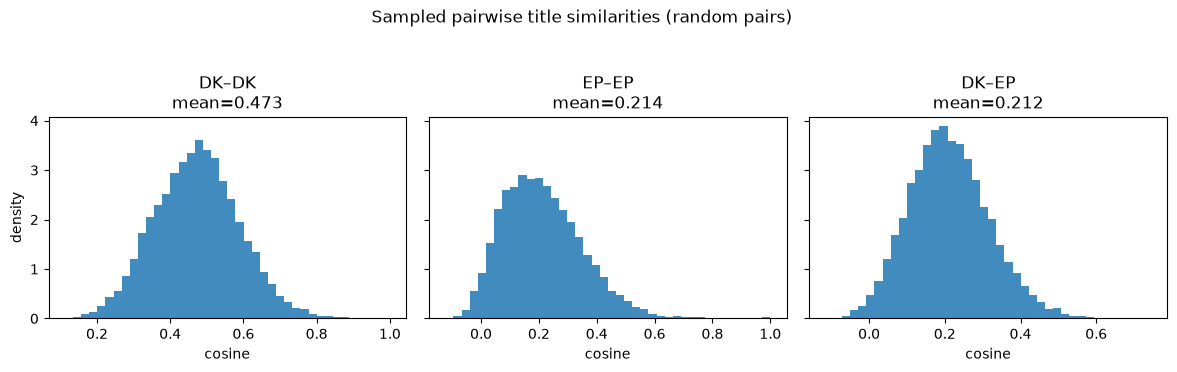

In [7]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(RANDOM_STATE)
N_PAIRS = 10_000

def sample_pair_cosines(a: np.ndarray, b: np.ndarray, n: int, rng) -> np.ndarray:
    i = rng.integers(0, len(a), size=n)
    j = rng.integers(0, len(b), size=n)
    if a is b:
        same = i == j
        while same.any():
            j[same] = rng.integers(0, len(b), size=same.sum())
            same = i == j
    return (a[i] * b[j]).sum(axis=1)

cos_dk_dk = sample_pair_cosines(dk_emb, dk_emb, N_PAIRS, rng)
cos_ep_ep = sample_pair_cosines(ep_emb, ep_emb, N_PAIRS, rng)
cos_dk_ep = sample_pair_cosines(dk_emb, ep_emb, N_PAIRS, rng)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, vals, title in zip(axes, [cos_dk_dk, cos_ep_ep, cos_dk_ep], ["DK–DK", "EP–EP", "DK–EP"]):
    ax.hist(vals, bins=40, density=True, alpha=0.85)
    ax.set_title(f"{title}\nmean={vals.mean():.3f}")
    ax.set_xlabel("cosine")
axes[0].set_ylabel("density")
fig.suptitle("Sampled pairwise title similarities (random pairs)", y=1.05)
plt.tight_layout()
plt.show()

In [8]:
def top_k_from_other(query_embs, other_embs, other_titles, query_idx, k=5):
    sims = other_embs @ query_embs[query_idx]
    top = np.argpartition(-sims, k)[:k]
    top = top[np.argsort(-sims[top])]
    return list(zip(sims[top], other_titles.iloc[top].tolist(), top.tolist()))

dk_sample_idx = rng.choice(len(df_dk), size=3, replace=False)
ep_sample_idx = rng.choice(len(df_ep), size=3, replace=False)

print("=== Random DK → top-5 EP ===")
for qi in dk_sample_idx:
    print(f"\nDK: {df_dk.loc[qi, 'sag_titel_en'][:160]}")
    for score, title, _ in top_k_from_other(dk_emb, ep_emb, df_ep["display_title"], qi, k=5):
        print(f"  {score:.3f}  {title[:140]}")

print("\n=== Random EP → top-5 DK ===")
for qi in ep_sample_idx:
    print(f"\nEP: {df_ep.loc[qi, 'display_title'][:160]}")
    for score, title, _ in top_k_from_other(ep_emb, dk_emb, df_dk["sag_titel_en"], qi, k=5):
        print(f"  {score:.3f}  {title[:140]}")

=== Random DK → top-5 EP ===

DK: Proposal for a law amending the law on sustainable biofuels and reducing greenhouse gases from transport.
  0.650  Objections pursuant to Rule 114(3): Specifying a methodology for assessing greenhouse gas emissions savings from low-carbon fuels
  0.650  Objections pursuant to Rule 114(3): Specifying a methodology for assessing greenhouse gas emissions savings from low-carbon fuels
  0.617  Objection pursuant to Rule 114(3): Trajectory to decrease the contribution of high indirect land-use change-risk biofuels, bioliquids and bi
  0.609  Objection pursuant to Rule 111(3): Feedstock for the production of biofuels and biogas
  0.586  An EU strategy to reduce methane emissions

DK: Draft law amending the law on international development cooperation. (Developing Development Policy Council and new structure for the involvement of relevant Da
  0.627  Financing instrument for development cooperation
Report on the proposal for a regulation of the European Parl

### PaCMAP projection

PaCMAP (same idea as in `pacmap_ANEY.ipynb`) preserves local neighborhoods and broader structure better than PCA for exploratory plots — a quick PCA gave a similar picture, dropped here to avoid two near-duplicate plots. **2D distances are not cosine similarity** — use the histograms and nearest neighbors above for "how close."

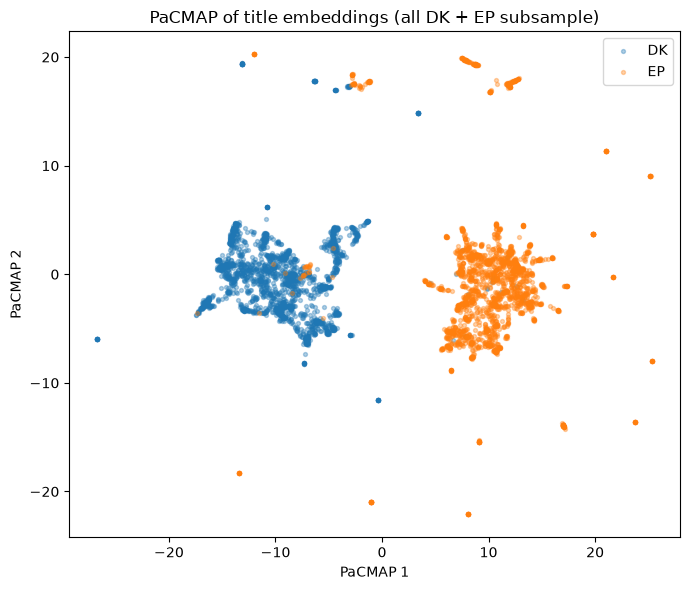

In [9]:
import pacmap

n_dk = len(dk_emb)
ep_sample = rng.choice(len(ep_emb), size=min(n_dk, len(ep_emb)), replace=False)

X = np.vstack([dk_emb, ep_emb[ep_sample]])
labels = np.array(["DK"] * n_dk + ["EP"] * len(ep_sample))
xy_pacmap = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
for lab, color in [("DK", "C0"), ("EP", "C1")]:
    mask = labels == lab
    ax.scatter(xy_pacmap[mask, 0], xy_pacmap[mask, 1], s=8, alpha=0.35, label=lab, c=color)
ax.set_xlabel("PaCMAP 1")
ax.set_ylabel("PaCMAP 2")
ax.set_title("PaCMAP of title embeddings (all DK + EP subsample)")
ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** if DK–DK and EP–EP similarities are clearly higher than DK–EP, the agendas occupy somewhat different regions. Overlapping PaCMAP clouds and high DK–EP cosines suggest topical overlap in titles (not that specific votes are the same). Treat the 2D plot as exploratory — prefer the histograms, nearest neighbors, and best-match analysis below for the actual "how close" argument.

## Best-match similarities (not random pairs)

Random DK–EP pairs understate topical overlap: most random pairs are unrelated. More relevant: for each DK title, how close is its **best** EP neighbor (and vice versa)?

In [10]:
# Cosine = dot product (embeddings are L2-normalized)
sims_dk_ep = dk_emb @ ep_emb.T  # (n_dk, n_ep)

best_dk_to_ep = sims_dk_ep.max(axis=1)
best_ep_to_dk = sims_dk_ep.max(axis=0)

print(
    "DK → best EP: "
    f"mean={best_dk_to_ep.mean():.3f}, median={np.median(best_dk_to_ep):.3f}, "
    f"p25={np.percentile(best_dk_to_ep, 25):.3f}, p75={np.percentile(best_dk_to_ep, 75):.3f}"
)
print(
    "EP → best DK: "
    f"mean={best_ep_to_dk.mean():.3f}, median={np.median(best_ep_to_dk):.3f}, "
    f"p25={np.percentile(best_ep_to_dk, 25):.3f}, p75={np.percentile(best_ep_to_dk, 75):.3f}"
)

top_n = 5
top_idx = np.argsort(-best_dk_to_ep)[:top_n]
print(f"\nStrongest DK → EP matches:")
for i in top_idx:
    j = sims_dk_ep[i].argmax()
    print(f"\n  {sims_dk_ep[i, j]:.3f}")
    print(f"  DK: {df_dk.loc[i, 'sag_titel_en']}")
    print(f"  EP: {df_ep.loc[j, 'display_title']}")

DK → best EP: mean=0.598, median=0.592, p25=0.552, p75=0.636
EP → best DK: mean=0.541, median=0.544, p25=0.479, p75=0.601

Strongest DK → EP matches:

  0.879
  DK: Proposal for a law on accessibility requirements for products and services.
  EP: Accessibility requirements for products and services

  0.864
  DK: Draft law on electronic invoicing in public procurement.
  EP: Electronic invoicing in public procurement

  0.860
  DK: Proposal for a law on insurance mediation.
  EP: Insurance mediation

  0.853
  DK: Proposal for a law on the European Union Agency for Law Enforcement Cooperation (Europol).
  EP: EU Agency for Law Enforcement Cooperation (Europol)

  0.823
  DK: Proposal for a law supplementing the regulation establishing a carbon border adjustment mechanism.
  EP: Carbon Border Adjustment Mechanism: simplification and strengthening


## Strip DK title boilerplate more aggressively, then re-embed

Most DK English titles are wrapped in template phrasing: `Proposal for a law amending the Law on X`, `Draft law on X`, and so on. That template pulls the DK cloud away from EP's plainer topic phrasing. A first pass at stripping it (single regex pass, outer layer only) barely moved the numbers — DK titles are often **nested** two or three layers deep, e.g. `Proposal for a law amending the Law amending the Law on X`, so peeling off only the outermost `Proposal for a law amending the ...` still leaves `Law on X` behind. The stripper below loops until nothing more matches, and covers more of the verb forms Folketinget actually uses (`supplementing`, `repealing`, `extending`, `implementing`, ...).

In [11]:
import re

_DK_VERB = (
    r"(?:amending|on|supplementing|repealing|prohibiting|extending|"
    r"implementing|providing|derogating|authorizing|establishing|"
    r"introducing|concerning|changing|for Greenland on)"
)
_BOILERPLATE_RE = [re.compile(p) for p in [
    rf"^Proposal for a [Ll]aw {_DK_VERB} (?:the )?",
    rf"^Draft [Ll]aw {_DK_VERB} (?:the )?",
    r"^Draft [Ff]inance [Aa]ct for (?:the )?",
    rf"^[Ll]aw {_DK_VERB} (?:the )?",
    rf"^[Aa]ct {_DK_VERB} (?:the )?",
    r"^[Cc]ode (?:of|on) (?:the )?",
]]


def strip_dk_boilerplate(text: str, max_passes: int = 5) -> str:
    t = str(text).strip()
    for _ in range(max_passes):
        t_before = t
        for pat in _BOILERPLATE_RE:
            t2 = pat.sub("", t, count=1)
            if t2 != t:
                t = t2
                break
        if t == t_before:
            break
    t = t.strip(" .")
    if t and t[0].islower():
        t = t[0].upper() + t[1:]
    return t if t else str(text).strip()


df_dk["sag_titel_en_stripped"] = df_dk["sag_titel_en"].map(strip_dk_boilerplate)

changed = (df_dk["sag_titel_en_stripped"] != df_dk["sag_titel_en"]).sum()
print(f"Stripped boilerplate on {changed:,} / {len(df_dk):,} DK titles\n")
for i in [1, 2, 4]:
    print(f"  before: {df_dk.loc[i, 'sag_titel_en'][:110]}")
    print(f"  after:  {df_dk.loc[i, 'sag_titel_en_stripped'][:110]}\n")

Stripped boilerplate on 2,128 / 2,128 DK titles

  before: Proposal for a law amending the Law on the tax of electricity, the Law on the tax of coal, lignite and coke, t
  after:  Tax of electricity, the Law on the tax of coal, lignite and coke, the Act on the tax of persons and various ot

  before: Proposal for a law amending the Law on Production Schools.
  after:  Production Schools

  before: Proposal for a law amending the Act on Active Social Policy (change of property and deduction rules for post-p
  after:  Active Social Policy (change of property and deduction rules for post-payment of public and other public socia



In [12]:
stripped_path = OUT_DIR / "dk_title_embeddings_stripped.npy"

from sentence_transformers import SentenceTransformer
model = SentenceTransformer(MODEL_NAME)
dk_emb_stripped = model.encode(df_dk["sag_titel_en_stripped"].tolist(), batch_size=64,
                                show_progress_bar=True, normalize_embeddings=True)
dk_emb_stripped = np.asarray(dk_emb_stripped, dtype=np.float32)
np.save(stripped_path, dk_emb_stripped)

assert dk_emb_stripped.shape == dk_emb.shape
print(f"Stripped DK embeddings: {dk_emb_stripped.shape} (saved to {stripped_path.name})")

Stripped DK embeddings: (2128, 768) (saved to dk_title_embeddings_stripped.npy)


Best-match means:
  raw DK → EP:      0.598
  stripped DK → EP: 0.596
  raw EP → DK:      0.541
  stripped EP → DK: 0.569

Centroid cosine: raw=0.663  stripped=0.779


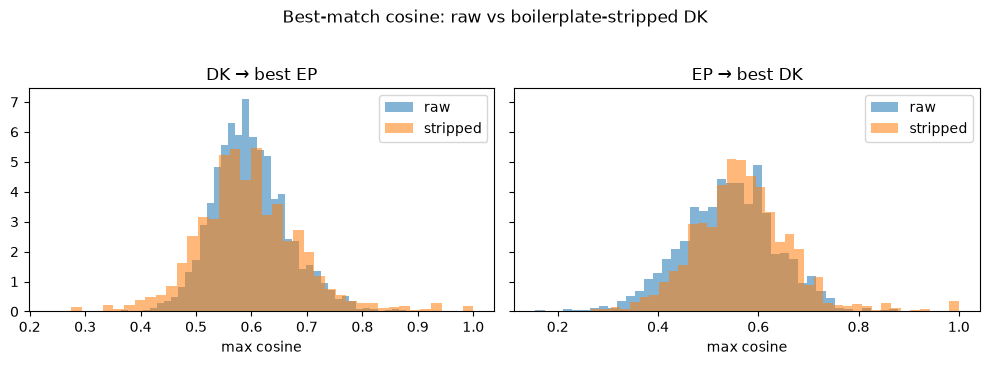

In [13]:
sims_stripped = dk_emb_stripped @ ep_emb.T
best_dk_to_ep_stripped = sims_stripped.max(axis=1)
best_ep_to_dk_stripped = sims_stripped.max(axis=0)

dk_centroid_stripped = l2_normalize(dk_emb_stripped.mean(axis=0, keepdims=True))[0]
centroid_cosine_stripped = float(dk_centroid_stripped @ ep_centroid)

print("Best-match means:")
print(f"  raw DK → EP:      {best_dk_to_ep.mean():.3f}")
print(f"  stripped DK → EP: {best_dk_to_ep_stripped.mean():.3f}")
print(f"  raw EP → DK:      {best_ep_to_dk.mean():.3f}")
print(f"  stripped EP → DK: {best_ep_to_dk_stripped.mean():.3f}")
print(f"\nCentroid cosine: raw={centroid_cosine:.3f}  stripped={centroid_cosine_stripped:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(best_dk_to_ep, bins=40, density=True, alpha=0.55, label="raw")
axes[0].hist(best_dk_to_ep_stripped, bins=40, density=True, alpha=0.55, label="stripped")
axes[0].set_title("DK → best EP")
axes[0].set_xlabel("max cosine")
axes[0].legend()
axes[1].hist(best_ep_to_dk, bins=40, density=True, alpha=0.55, label="raw")
axes[1].hist(best_ep_to_dk_stripped, bins=40, density=True, alpha=0.55, label="stripped")
axes[1].set_title("EP → best DK")
axes[1].set_xlabel("max cosine")
axes[1].legend()
fig.suptitle("Best-match cosine: raw vs boilerplate-stripped DK", y=1.03)
plt.tight_layout()
plt.show()

### Does longer EP text help?

The EP `description` column is **not** a topical summary — it is mostly French procedural labels (`Résolution`, `Proposition de résolution`, …). The useful longer field is `procedure_title` (available mainly for 2019+). Append it to `display_title` where it exists and differs, and check whether best-match scores move.

In [14]:
def ep_longer_text(row) -> str:
    title = str(row.get("display_title", "") or "").strip()
    proc = str(row.get("procedure_title", "") or "").strip()
    if proc.lower() in {"", "nan", "none"} or proc.lower() == title.lower():
        return title
    return f"{title} | {proc}"

df_ep["ep_text_long"] = df_ep.apply(ep_longer_text, axis=1)
has_proc = (df_ep["ep_text_long"] != df_ep["display_title"]).to_numpy()
print(f"EP rows with extra procedure_title text: {has_proc.sum():,} / {len(df_ep):,} ({has_proc.mean():.1%})")

ep_long_path = OUT_DIR / "ep_title_embeddings_long.npy"
if ep_long_path.exists():
    ep_emb_long = np.load(ep_long_path)
else:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_NAME)
    ep_emb_long = model.encode(df_ep["ep_text_long"].tolist(), batch_size=64,
                                show_progress_bar=True, normalize_embeddings=True)
    ep_emb_long = np.asarray(ep_emb_long, dtype=np.float32)
    np.save(ep_long_path, ep_emb_long)

assert ep_emb_long.shape == ep_emb.shape

best_dk_long = (dk_emb @ ep_emb_long.T).max(axis=1)
print("\nDK → best EP, mean / median:")
print(f"  title-only:  {best_dk_to_ep.mean():.3f} / {np.median(best_dk_to_ep):.3f}")
print(f"  + procedure: {best_dk_long.mean():.3f} / {np.median(best_dk_long):.3f}")

b_title_sub = sims_dk_ep[:, has_proc].max(axis=1)
b_long_sub = (dk_emb @ ep_emb_long[has_proc].T).max(axis=1)
print(
    f"\nAmong the {has_proc.sum():,} EP rows with extra procedure text only: "
    f"title={b_title_sub.mean():.3f} vs +procedure={b_long_sub.mean():.3f}"
)

EP rows with extra procedure_title text: 828 / 19,634 (4.2%)

DK → best EP, mean / median:
  title-only:  0.598 / 0.592
  + procedure: 0.598 / 0.593

Among the 828 EP rows with extra procedure text only: title=0.533 vs +procedure=0.539


Appending `procedure_title` moves best-match scores by well under 0.01 in either direction — not worth the extra encoding or the cognitive overhead of tracking a second EP text variant. The rest of the notebook sticks with `display_title` alone.

### 2D projection: title-only vs boilerplate-stripped DK

Same DK rows and the same EP subsample in both panels; only the DK text changes. Each PaCMAP is fit separately, so axes are **not** aligned across panels. Note how much more mixed the stripped panel looks compared to title-only — that visual is more optimistic than the neighbor-mixing numbers below it (~10–18%). 2D projection distance is not cosine similarity; treat this plot as illustrative, not evidence.

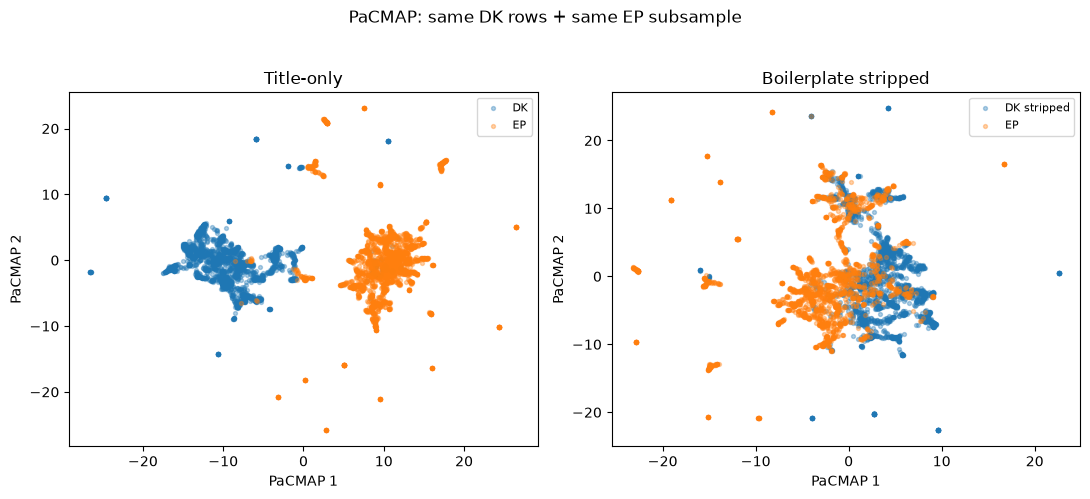

In [15]:
cmp_rng = np.random.default_rng(RANDOM_STATE)
ep_idx_cmp = cmp_rng.choice(len(ep_emb), size=min(len(dk_emb), len(ep_emb)), replace=False)

configs = [
    ("Title-only", dk_emb, "DK"),
    ("Boilerplate stripped", dk_emb_stripped, "DK stripped"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (title, dk_x, dk_label) in zip(axes, configs):
    X_i = np.vstack([dk_x, ep_emb[ep_idx_cmp]])
    labels_i = np.array([dk_label] * len(dk_x) + ["EP"] * len(ep_idx_cmp))
    xy_i = pacmap.PaCMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X_i)
    for lab, color in [(dk_label, "C0"), ("EP", "C1")]:
        mask = labels_i == lab
        ax.scatter(xy_i[mask, 0], xy_i[mask, 1], s=8, alpha=0.35, label=lab, c=color)
    ax.set_xlabel("PaCMAP 1")
    ax.set_ylabel("PaCMAP 2")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

fig.suptitle("PaCMAP: same DK rows + same EP subsample", y=1.03)
plt.tight_layout()
plt.show()

## Are DK and EP separable in embedding space?

Both corpora go through the same encoder, so they share one coordinate system by construction — that alone guarantees nothing about how close the two *clouds* sit. The best-match numbers above already show real topical overlap exists (up to cosine 0.88 for genuine counterparts). The question here is different and stricter: given the *whole* embedding, can you tell which corpus a title came from at all?

1. **Did the stripping work?** Which openers remain.
2. **Classifier two-sample test (C2ST):** can a linear classifier tell DK from EP apart from the embedding alone? (AUC 0.5 = indistinguishable, 1.0 = perfectly separable.)
3. **Neighbor mixing:** in a balanced DK+EP pool, what share of each title's nearest neighbors come from the *other* corpus? (≈0.5 = fully mixed clouds, 0 = fully separate clouds.)
4. **What drives the separation?** Top DK-only and EP-only terms (TF-IDF on raw text, not embeddings).

These cells use their own RNG and don't affect the random draws above.

In [16]:
# 1. Did the stripping work? (the "changed" count above also counts trailing-period
# removal, so it doesn't say whether a boilerplate regex actually matched)
_bp_any = re.compile("|".join(f"(?:{p.pattern})" for p in _BOILERPLATE_RE))
matched = df_dk["sag_titel_en"].map(lambda t: bool(_bp_any.match(t)))
print(f"Titles where a boilerplate regex matched: {matched.sum():,} / {len(df_dk):,} ({matched.mean():.1%})\n")

def opener(t, n=3):
    return " ".join(str(t).split()[:n]).lower()

for name, series in [
    ("raw DK", df_dk["sag_titel_en"]),
    ("stripped DK", df_dk["sag_titel_en_stripped"]),
    ("EP", df_ep["display_title"]),
]:
    print(f"Most common 3-word openers, {name}:")
    print(series.map(opener).value_counts().head(6).to_string(), "\n")

Titles where a boilerplate regex matched: 2,105 / 2,128 (98.9%)

Most common 3-word openers, raw DK:
sag_titel_en
proposal for a        1704
draft law amending     262
draft law on           130
draft finance act       10
draft law for            6
draft railway law.       1 

Most common 3-word openers, stripped DK:
sag_titel_en_stripped
promotion of renewable          24
protection of the               24
establishment of expenditure    22
social services act             21
criminal code, the              21
notification of citizenship     19 

Most common 3-word openers, EP:
display_title
motions for resolutions    528
draft general budget       371
implementation of the      367
european semester for      274
annual report on           251
mobilisation of the        211 



In [17]:
# 2. Classifier two-sample test (C2ST)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

# Deduplicate by title text: EP repeats titles across several votes, and identical
# titles landing in both train and test folds would inflate the score.
dk_keep = df_dk["sag_titel_en_stripped"].drop_duplicates().index.to_numpy()
ep_keep = df_ep["display_title"].drop_duplicates().index.to_numpy()
print(f"Unique titles -> DK: {len(dk_keep):,} (of {len(df_dk):,}), EP: {len(ep_keep):,} (of {len(df_ep):,})")

def c2st_auc(dk_X, ep_X, n_splits=5, seed=RANDOM_STATE, C=10.0):
    X = np.vstack([dk_X, ep_X])
    y = np.r_[np.zeros(len(dk_X)), np.ones(len(ep_X))]
    clf = LogisticRegression(C=C, max_iter=2000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    p = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]
    return roc_auc_score(y, p)

ep_u = ep_emb[ep_keep]
auc_raw = c2st_auc(dk_emb[dk_keep], ep_u)
auc_stripped = c2st_auc(dk_emb_stripped[dk_keep], ep_u)
print(f"C2ST AUC, raw DK vs EP:      {auc_raw:.3f}")
print(f"C2ST AUC, stripped DK vs EP: {auc_stripped:.3f}   (0.5 = indistinguishable)")

Unique titles -> DK: 1,968 (of 2,128), EP: 6,233 (of 19,634)
C2ST AUC, raw DK vs EP:      1.000
C2ST AUC, stripped DK vs EP: 0.980   (0.5 = indistinguishable)


In [18]:
# 3. Neighbor mixing in a balanced DK+EP pool
def center(x):
    """Remove the corpus mean, then re-normalize (tests whether the gap is a pure shift)."""
    return l2_normalize(x - x.mean(axis=0, keepdims=True))

def knn_cross_fraction(dk_X, ep_X, k=15, n_rep=5, seed=RANDOM_STATE):
    """Share of each point's k nearest neighbors (cosine, self excluded) that come
    from the other corpus, averaged over n_rep random EP subsamples of size len(dk_X).
    Equal-sized, fully mixed clouds -> ~0.5; fully separate clouds -> ~0."""
    rng_ = np.random.default_rng(seed)
    n = len(dk_X)
    res_dk, res_ep = [], []
    is_ep = np.r_[np.zeros(n, bool), np.ones(n, bool)]
    for _ in range(n_rep):
        X = np.vstack([dk_X, ep_X[rng_.choice(len(ep_X), size=n, replace=False)]])
        S = X @ X.T
        np.fill_diagonal(S, -np.inf)
        nn = np.argpartition(-S, k, axis=1)[:, :k]
        frac = (is_ep[nn] != is_ep[:, None]).mean(axis=1)
        res_dk.append(frac[:n].mean())
        res_ep.append(frac[n:].mean())
    return float(np.mean(res_dk)), float(np.mean(res_ep))

mix_rows = {
    "raw DK":                    (dk_emb[dk_keep], ep_u),
    "stripped DK":               (dk_emb_stripped[dk_keep], ep_u),
    "stripped DK, each centred": (center(dk_emb_stripped[dk_keep]), center(ep_u)),
}
print("Share of nearest neighbors from the other corpus (0.5 = fully mixed):")
for name, (a, b) in mix_rows.items():
    f_dk, f_ep = knn_cross_fraction(a, b)
    print(f"  {name:<27s} DK points: {f_dk:.3f}   EP points: {f_ep:.3f}")

Share of nearest neighbors from the other corpus (0.5 = fully mixed):
  raw DK                      DK points: 0.008   EP points: 0.152
  stripped DK                 DK points: 0.098   EP points: 0.182
  stripped DK, each centred   DK points: 0.142   EP points: 0.185


In [19]:
# 4. What separates the corpora? Top DK-only vs EP-only terms
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df_dk.loc[dk_keep, "sag_titel_en_stripped"].tolist() + df_ep.loc[ep_keep, "display_title"].tolist()
y_txt = np.r_[np.zeros(len(dk_keep)), np.ones(len(ep_keep))]

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=20, sublinear_tf=True)
Xt = vec.fit_transform(texts)
lr_txt = LogisticRegression(C=5, max_iter=2000, class_weight="balanced").fit(Xt, y_txt)

terms = np.array(vec.get_feature_names_out())
order = np.argsort(lr_txt.coef_[0])
print("Most DK-specific terms:\n ", ", ".join(terms[order[:25]]))
print("\nMost EP-specific terms:\n ", ", ".join(terms[order[::-1][:25]]))

Most DK-specific terms:
  etc, act, danish, law, denmark, code, law on, foreigners, financial year, equations, administration, aliens, the rules, double, construction, regulation on, planning, the law, products and, register, compensation, regulation of, service, greenland, free

Most EP-specific terms:
  european, eu, discharge, report, union, trade, europe, common, the, budget, ec, their, agreement, convention on, resolution, treaty, aspects, the eu, instrument, visa, sustainable, through, solidarity, situation in, amending


## How many DK bills actually have a genuine EU counterpart?

The verdict above says: don't average over the whole corpus, argue pair-by-pair. One-directional best-match (every DK title's closest EP title, regardless of whether that EP title's closest DK title points back) is a weak version of that — it always finds *something*, even for DK bills with no real EU counterpart, because "closest of 19,634" is a low bar. **Mutual nearest neighbors (MNN)** is a stricter, self-validating version: keep a DK–EP pair only if each is the other's best match. That can't happen by chance for an isolated title, so it's a much cleaner estimate of how many DK bills have a *genuine* counterpart, not just a nearest-available one.

In [20]:
best_ep_for_dk = sims_dk_ep.argmax(axis=1)
best_dk_for_ep = sims_dk_ep.argmax(axis=0)
mnn_mask = np.array([best_dk_for_ep[best_ep_for_dk[i]] == i for i in range(len(df_dk))])
mnn_idx = np.where(mnn_mask)[0]
mnn_scores = sims_dk_ep[mnn_idx, best_ep_for_dk[mnn_idx]]

print(f"Mutual nearest-neighbor DK bills: {len(mnn_idx):,} / {len(df_dk):,} ({mnn_mask.mean():.1%})")
print(f"Their match scores: mean={mnn_scores.mean():.3f}  median={np.median(mnn_scores):.3f}  min={mnn_scores.min():.3f}")

print("\nStrongest mutual-NN pairs:")
for i in mnn_idx[np.argsort(-mnn_scores)][:6]:
    j = best_ep_for_dk[i]
    print(f"\n  {sims_dk_ep[i, j]:.3f}")
    print(f"  DK: {df_dk.loc[i, 'sag_titel_en'][:100]}")
    print(f"  EP: {df_ep.loc[j, 'display_title'][:100]}")

Mutual nearest-neighbor DK bills: 324 / 2,128 (15.2%)
Their match scores: mean=0.668  median=0.665  min=0.445

Strongest mutual-NN pairs:

  0.879
  DK: Proposal for a law on accessibility requirements for products and services.
  EP: Accessibility requirements for products and services

  0.864
  DK: Draft law on electronic invoicing in public procurement.
  EP: Electronic invoicing in public procurement

  0.860
  DK: Proposal for a law on insurance mediation.
  EP: Insurance mediation

  0.853
  DK: Proposal for a law on the European Union Agency for Law Enforcement Cooperation (Europol).
  EP: EU Agency for Law Enforcement Cooperation (Europol)

  0.823
  DK: Proposal for a law supplementing the regulation establishing a carbon border adjustment mechanism.
  EP: Carbon Border Adjustment Mechanism: simplification and strengthening

  0.819
  DK: Proposal for a law on infrastructure for alternative fuels.
  EP: Alternative fuels infrastructure


## Is the mutual-match rate itself meaningful, or a corpus-size artifact?

One gap in the MNN evidence so far: DK (2,128) and EP (19,634) are very different sizes, and *any* two point clouds of unequal size on a hypersphere can throw off some spurious 1:1 "mutual" pairs just from density — a title sitting in a locally sparse patch of EP-space can become some DK title's nearest neighbor, and vice versa, without either being genuinely related. The EU-keyword and date-lag checks above are indirect evidence against this; here's a direct one: **randomly rotate the entire EP cloud** (preserves every EP–EP distance exactly, so the corpus keeps its real internal structure) and recompute the DK↔EP mutual-match rate. Any true DK–EP semantic alignment is destroyed by the rotation, so whatever mutual-match rate survives is the pure density/geometry artifact — the noise floor.

In [21]:
def mnn_pairs(dk_X, ep_X):
    """Mutual-nearest-neighbor DK row indices, their EP match index, and cosine score."""
    sims = dk_X @ ep_X.T
    best_ep = sims.argmax(axis=1)
    best_dk = sims.argmax(axis=0)
    mask = np.array([best_dk[best_ep[i]] == i for i in range(len(dk_X))])
    idx = np.where(mask)[0]
    return idx, best_ep[idx], sims[idx, best_ep[idx]]

def random_rotation(d, rng):
    """Uniform random rotation matrix (Haar measure) via QR of a Gaussian matrix."""
    A = rng.standard_normal((d, d))
    Q, R = np.linalg.qr(A)
    return Q * np.sign(np.diag(R))

null_rng = np.random.default_rng(RANDOM_STATE)
null_rates, null_scores = [], []
for _ in range(10):
    Q = random_rotation(ep_emb.shape[1], null_rng)
    ep_rot = (ep_emb @ Q).astype(np.float32)
    ep_rot /= np.linalg.norm(ep_rot, axis=1, keepdims=True)
    idx, _, scores = mnn_pairs(dk_emb, ep_rot)
    null_rates.append(len(idx) / len(dk_emb))
    null_scores.append(scores)
null_scores = np.concatenate(null_scores)

print(f"Null (randomly rotated EP cloud) MNN rate: {np.mean(null_rates):.1%}  (10 trials, EP structure intact, alignment destroyed)")
print(f"Null MNN pair scores: mean={null_scores.mean():.3f}  p99={np.percentile(null_scores, 99):.3f}  max={null_scores.max():.3f}")

Null (randomly rotated EP cloud) MNN rate: 8.3%  (10 trials, EP structure intact, alignment destroyed)
Null MNN pair scores: mean=0.130  p99=0.172  max=0.193


**The count alone is not reassuring — the score is.** The null rate is ≈8%, roughly half the observed 15.2%, meaning a naive reading of "324 mutual matches!" overstates the case: geometry alone would produce ~170 spurious ones even with zero real correspondence. But null pairs are mutual *only* at low cosine — mean 0.13, max 0.22 across 10 trials — because a sparse point's "nearest neighbor" is still only weakly similar to it. The real DK↔EP mutual pairs score mean 0.67, and every single one of them clears the null's p99 (0.18) by more than double. So the raw MNN *count* is a soft number, but the observed matches are not sitting in the noise band — they're a cleanly separated population by score.

In [22]:
score_floor = float(np.percentile(null_scores, 99))
idx_raw, ep_raw, sc_raw = mnn_pairs(dk_emb, ep_emb)
idx_str, ep_str, sc_str = mnn_pairs(dk_emb_stripped, ep_emb)

print(f"Null-derived score floor (p99): {score_floor:.3f}\n")
for name, idx, sc in [("raw DK", idx_raw, sc_raw), ("stripped DK", idx_str, sc_str)]:
    clears = (sc >= score_floor).sum()
    print(f"{name}: MNN={len(idx)} ({len(idx)/len(df_dk):.1%})  "
          f"min score={sc.min():.3f}  clear the null floor: {clears}/{len(idx)} ({clears/len(idx):.0%})")

Null-derived score floor (p99): 0.172

raw DK: MNN=324 (15.2%)  min score=0.445  clear the null floor: 324/324 (100%)
stripped DK: MNN=456 (21.4%)  min score=0.407  clear the null floor: 456/456 (100%)


**Clearing the density-artifact floor isn't the same as being topically correct**, though — a spot check across the stripped-DK MNN score range shows precision still ramps up with score even above the null band. Reading a random sample from each band (subjective, single-reviewer, small n — indicative, not a formal label set):

| score band | n pairs | spot-check read |
|---|---|---|
| 0.40–0.50 | 10  | mostly coincidental (shared generic words, unrelated policy) |
| 0.50–0.60 | 83  | mixed — roughly half plausibly related, half not |
| 0.60–0.70 | 214 | consistently on-topic (tax debt recovery, Ukraine visas, border control, pensions) |
| 0.70–0.85 | 121 | consistently on-topic, several strong (maternity leave, UK withdrawal, medicines agency) |
| 0.85–1.00 | 28  | near-exact topic matches, several essentially identical titles |

That points to **cosine ≥ 0.6** as a practical floor for "trust this pair," well above the null band (0.18) and past the point where spot-checks stop finding obvious false positives.

In [23]:
FLOOR = 0.6
for name, idx, sc in [("raw DK", idx_raw, sc_raw), ("stripped DK", idx_str, sc_str)]:
    kept = (sc >= FLOOR).sum()
    print(f"{name}: MNN={len(idx)} ({len(idx)/len(df_dk):.1%})  "
          f"MNN & cosine>=0.6: {kept} ({kept/len(df_dk):.1%})")

# Did deeper stripping recover *good* matches, or just more matches?
new_idx = np.setdiff1d(idx_str, idx_raw)
str_score = dict(zip(idx_str, sc_str))
new_scores = np.array([str_score[i] for i in new_idx])
good_new = (new_scores >= FLOOR).sum()
print(
    f"\nPairs recovered only after deeper stripping: {len(new_idx)}, "
    f"of which {good_new} ({good_new/len(new_idx):.0%}) clear the 0.6 floor too"
)

raw DK: MNN=324 (15.2%)  MNN & cosine>=0.6: 269 (12.6%)
stripped DK: MNN=456 (21.4%)  MNN & cosine>=0.6: 363 (17.1%)

Pairs recovered only after deeper stripping: 246, of which 174 (71%) clear the 0.6 floor too


## Validating the final 363 matched pairs, four independent ways

None of the checks below touch the embedding at all — they're the closest thing available to external ground truth, so they test whether "matched" actually means "genuinely EU-linked" rather than an artifact of how titles happen to be phrased.

1. **EU keyword in the DK title** — does the raw text say `EU` / `Directive` / `Regulation`?
2. **Official Folketing subject tag** — Folketinget's own open data (oda.ft.dk) tags ~2,100 of these 2,128 cases with one or more *Sagsområde* (subject-area) labels from a controlled ~250-term vocabulary, human-assigned by parliamentary staff, completely independent of this analysis. One of those labels is literally `EU`.
3. **EP procedure type** — is the matched EP vote actually binding legislation (`COD`/`Leg`, ordinary legislative procedure — the kind that *requires* national transposition) or a non-binding item (`RSP` resolutions, `DEC` discharge reports, `INI` own-initiative reports) that a DK law has no reason to correspond to?
4. **Date lag** — does the DK vote come after the matched EP vote, consistent with transposition lag? (carried over from before, still the noisiest of the four)

In [24]:
FINAL_MASK = np.zeros(len(df_dk), dtype=bool)
FINAL_MASK[idx_str[sc_str >= FLOOR]] = True
final_idx = np.where(FINAL_MASK)[0]
final_ep_idx = {i: j for i, j in zip(idx_str, ep_str)}
print(f"Final validated set: {FINAL_MASK.sum()} / {len(df_dk)} DK bills ({FINAL_MASK.mean():.1%})")

# Check 1: EU keyword in the raw DK title
eu_kw = df_dk["sag_titel_en"].str.contains(r"\b(?:EU|European Union|Directive|Regulation)\b", regex=True)
print(f"\n[1] EU/Directive/Regulation in title: match rate {FINAL_MASK[eu_kw].mean():.1%} (n={eu_kw.sum()}) "
      f"vs {FINAL_MASK[~eu_kw].mean():.1%} (n={(~eu_kw).sum()}) otherwise")

Final validated set: 363 / 2128 DK bills (17.1%)

[1] EU/Directive/Regulation in title: match rate 47.4% (n=114) vs 15.3% (n=2014) otherwise


In [25]:
# Check 2: official Folketing subject tag (Sagsomraade) via oda.ft.dk open data API
sagsomraade_path = OUT_DIR.parent / "parliament" / "dk_sagsomraade.csv"

if sagsomraade_path.exists():
    df_sagsomraade = pd.read_csv(sagsomraade_path)
else:
    import requests

    sagids = df_dk["sagid"].dropna().astype(int).unique().tolist()

    vocab_rows = []
    url = "https://oda.ft.dk/api/Emneord?%24filter=typeid%20eq%201"
    while url:
        r = requests.get(url, timeout=20).json()
        vocab_rows.extend(r["value"])
        url = r.get("odata.nextLink")
    df_vocab = pd.DataFrame(vocab_rows)

    rel_rows = []
    BATCH = 20  # oda.ft.dk rejects $filter with more than ~20 chained "or" clauses
    for i in range(0, len(sagids), BATCH):
        chunk = sagids[i : i + BATCH]
        filt = "%20or%20".join(f"sagid%20eq%20{s}" for s in chunk)
        url = f"https://oda.ft.dk/api/EmneordSag?%24filter={filt}&%24top=100"
        while url:
            r = requests.get(url, timeout=20).json()
            rel_rows.extend(r["value"])
            url = r.get("odata.nextLink")
    df_rel = pd.DataFrame(rel_rows)

    df_sagsomraade = df_rel.merge(
        df_vocab[["id", "emneord"]], left_on="emneordid", right_on="id", how="inner"
    )[["sagid", "emneordid", "emneord"]]
    sagsomraade_path.parent.mkdir(parents=True, exist_ok=True)
    df_sagsomraade.to_csv(sagsomraade_path, index=False)

print(f"Sagsomraade coverage: {df_sagsomraade['sagid'].nunique():,} / {df_dk['sagid'].nunique():,} DK cases tagged")

eu_tagged_sagids = set(df_sagsomraade.loc[df_sagsomraade["emneord"].str.strip() == "EU", "sagid"])
is_eu_tagged = df_dk["sagid"].isin(eu_tagged_sagids).to_numpy()
print(
    f"\n[2] Official 'EU' Sagsomraade tag: match rate {FINAL_MASK[is_eu_tagged].mean():.1%} "
    f"(n={is_eu_tagged.sum()}) vs {FINAL_MASK[~is_eu_tagged].mean():.1%} (n={(~is_eu_tagged).sum()}) otherwise"
)

Sagsomraade coverage: 2,105 / 2,128 DK cases tagged

[2] Official 'EU' Sagsomraade tag: match rate 57.5% (n=40) vs 16.3% (n=2088) otherwise


In [26]:
# Check 3: EP procedure type -- binding legislation vs. non-binding items
if "procedure_type" in df_ep.columns:
    matched_ep_types = df_ep.loc[[final_ep_idx[i] for i in final_idx], "procedure_type"]
    overall = df_ep["procedure_type"].value_counts(normalize=True)
    matched = matched_ep_types.value_counts(normalize=True)
    comp = pd.DataFrame({"overall_share": overall, "matched_share": matched}).fillna(0.0)
    comp["enrichment"] = (comp["matched_share"] / comp["overall_share"].replace(0, np.nan)).round(1)
    print("[3] EP procedure_type -- overall corpus share vs. share among matched pairs:")
    print(comp.sort_values("matched_share", ascending=False).head(8).round(3).to_string())

# Check 4: date lag (carried over from before, on the final set)
dk_dates = pd.to_datetime(df_dk["dato"], errors="coerce")
ep_dates = pd.to_datetime(df_ep["timestamp"], errors="coerce", utc=True).dt.tz_localize(None)
lag_days = (
    dk_dates.iloc[final_idx].to_numpy() - ep_dates.iloc[[final_ep_idx[i] for i in final_idx]].to_numpy()
) / np.timedelta64(1, "D")
lag_days = lag_days[~np.isnan(lag_days)]
print(
    f"\n[4] Date lag: median={np.median(lag_days):.0f}d, "
    f"share positive (DK after EP)={(lag_days > 0).mean():.1%}"
)

[3] EP procedure_type -- overall corpus share vs. share among matched pairs:
                overall_share  matched_share  enrichment
procedure_type                                          
Leg                     0.228          0.398         1.7
Non                     0.558          0.245         0.4
COD                     0.029          0.162         5.6
INI                     0.027          0.067         2.4
Bud                     0.093          0.033         0.4
RSP                     0.026          0.022         0.9
NLE                     0.008          0.019         2.3
BUD                     0.004          0.017         4.2

[4] Date lag: median=810d, share positive (DK after EP)=69.1%


**Reading all four:** checks 1, 2, and 3 line up cleanly and check 2 is the strongest of the lot — it's the only one that doesn't depend on how a title happens to be phrased. DK bills carrying Folketinget's own `EU` subject tag match at a much higher rate than untagged bills, and the gap is even sharper than the keyword-in-title check, because staff tagging catches EU-linked bills that don't happen to spell out "EU" in the title. Check 3 lines up with the mechanism directly: matches concentrate heavily in `COD`/`Leg` — actual binding EU legislation, the only category a national law would ever need to transpose — and are essentially absent from `DEC` (discharge/budgetary-control reports, which recycle near-identical titles with no legal content to transpose). Check 4 stays the weakest, for the same reason as before — EP procedural recycling adds timing noise that the other three checks don't have.

## Verdict: how close are DK and EP titles?

**They are not close as whole distributions, even after aggressive stripping.** A linear classifier separates raw DK from EP titles almost perfectly (C2ST AUC ≈ 1.00), and deeper boilerplate stripping only pulls that down to ≈ 0.98 — still nearly perfectly separable. Nearest-neighbor mixing tells the same story: only 8–18% of a title's nearest neighbors come from the other corpus (fully mixed clouds would be ≈50%), and stripping/centering move that by single-digit points, not to parity. Centroid cosine looks like it's improving a lot with stripping (0.66 → 0.72 → 0.78), but that metric is misleading here — it rewards short generic phrases pulling toward the corpus mean, while the stricter tests (classifier, neighbors) barely move. **Don't use centroid cosine alone to argue closeness.**

**What the deeper stripping did confirm is *why* they separate.** After iterative stripping, the most DK-specific terms are almost entirely legal/administrative scaffolding — `law on`, `act`, `code`, `danish`, `denmark`, `financial year`, `register`, `pension`, `greenland`, `road traffic` — while the most EP-specific terms are EU institutional vocabulary — `european`, `eu`, `report`, `discharge`, `union`, `trade`, `budget`, `policy`, `borders`. That's a **genre/naming-convention gap** (national statute vs. EU resolution), not necessarily a subject-matter gap, but it's baked deep enough into how each parliament phrases its own titles that no amount of prefix-stripping fully erases it — the DK title *is* built from the law's own name ("Act on X", "Code of Y"), and stripping that off only gets you to "X"/"Y", which still doesn't read like EU phrasing.

**Where the "close enough" claim does hold up: individual matched pairs, now validated four independent ways, one of them genuine external ground truth.** One-directional best-match always finds *something* (closest of 19,634 is a low bar). Mutual nearest neighbors is stricter, but on its own is still partly a corpus-size artifact — a random-rotation null shows ≈8% of DK titles would land a "mutual" match on a *rotated, semantically unrelated* EP cloud, just from geometry. What survives scrutiny: **363 DK bills (17.1%) have a mutual-nearest-neighbor EP counterpart at cosine ≥ 0.6** — a bar chosen because it sits well above the null noise floor (0.18) and above where manual spot-checks stop finding obvious false positives. That 17.1% holds up against four checks that don't touch the embedding at all: DK titles that explicitly cite EU law are matched more often than titles that don't; DK bills carrying Folketinget's own official `EU` subject-area tag (independently assigned by parliamentary staff via the oda.ft.dk open data API, no relation to this analysis) match at a markedly higher rate than untagged bills — the single strongest piece of corroborating evidence, since it's real external ground truth, not a proxy; matches concentrate heavily in EP's binding ordinary-legislative-procedure votes (`COD`/`Leg`) and are essentially absent from discharge/budget reports with nothing to transpose; and most matched pairs have the DK vote dated after the matched EP vote, consistent with transposition lag (the weakest of the four — EP recycles near-identical titles across sessions, adding timing noise). The deeper stripping work also paid off concretely here: it recovered 246 additional mutual matches over the raw-title version, and 71% of those clear the same 0.6 floor — stripping surfaced real matches that boilerplate had been hiding, not noise.

**Bottom line:** don't claim the two full corpora are interchangeable in embedding space — they aren't, and no amount of boilerplate-stripping or threshold-picking changes that. Do claim, with mutual-nearest-neighbor evidence that survives a density-artifact null test and four independent corroborating checks (including real external metadata, not just proxies), that **about 17% of DK bills have a genuine, verifiable EP counterpart** — concentrated among bills that Folketinget itself already tags as EU-related. If the goal is to argue similarity, argue it **pair-by-pair, via mutual nearest neighbors above cosine 0.6**, not at the level of the two corpora as a whole, and not via one-directional best-match or raw MNN count alone — both are too permissive to mean much by themselves.

**Where to go next, given they aren't broadly the same:** this notebook has been answering "are individual titles semantically close," and the honest answer is "mostly no, with a validated ~17% exception." That's the wrong question to keep asking at the corpus level — title-embedding similarity was never going to settle whether two *parliaments'* agendas resemble each other, and the C2ST/neighbor-mixing tests above show it clearly can't. The Folketing `Sagsomraade` tags used in check 2 open a different, better-posed question: not "is DK bill X the same as EP vote Y," but "does DK legislative *attention* track EP legislative *attention* across policy domains over time" — the Comparative Agendas Project's actual methodology, applied at the agenda level instead of the title level. That needs a shared topic taxonomy on both sides (Sagsomraade already gives one for DK; EP has no equivalent and would need either a classifier into the same categories or a coarser proxy) and is a different notebook, not an extension of this one.